add_two a=3 b=5 c=7
add_three a=8 b=5 c=7
make_odd a=20 b=5 c=7
after_make_odd a=21 b=5 c=7
mul_three a=21 b=5 c=7
{'a': 735, 'b': 5, 'c': 7}


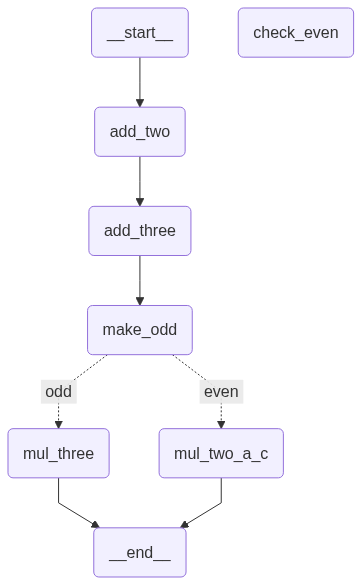

In [5]:


from pydantic import BaseModel
from langgraph.graph import StateGraph, START, END

class MyState(BaseModel):
    # docs: List[Document] = []  # List of Document objects
    # splitted_docs: List[Document] = []  # List of split Document objects
    # vectorstore: Optional[Chroma] = None  # Optional Chroma vectorstore
    # retriever: Optional[object] = None  # Optional retriever object
    a: int = 0  # Integer field with default value 0
    b: int = 0  # Integer field with default value 0
    c: int = 0  # Integer field with default value 0
    
    
graph = StateGraph(state_schema=MyState)

def add_two(state: MyState):
    print("add_two", state)
    state.a = state.a + state.b
    return state

def add_three(state: MyState):
    print("add_three", state)
    state.a = state.a + state.b + state.c
    return state

def mul_two_a_c(state: MyState):
    print("mul_two_ac", state)
    state.a = state.a * state.c
    return state

def mul_three(state: MyState):
    print("mul_three", state)
    state.a = state.a * state.b* state.c
    return state

def check_if_even(state: MyState):
    return "even" if state.a % 2 == 0 else "odd"

def make_odd(state: MyState):
    print("make_odd", state)
    state.a = state.a + 1 if state.a % 2 == 0 else state.a
    print("after_make_odd", state)
    return state

graph.add_node("add_two", add_two)
graph.add_node("add_three", add_three)
graph.add_node("make_odd", make_odd)
graph.add_node("check_even", check_if_even)
graph.add_node("mul_two_a_c", mul_two_a_c)
graph.add_node("mul_three", mul_three)

graph.add_edge(START, "add_two")
graph.add_edge("add_two","add_three")
graph.add_edge("add_three","make_odd")
graph.add_conditional_edges("make_odd",check_if_even, { "even": "mul_two_a_c", "odd": "mul_three"})
graph.add_edge("mul_two_a_c", END)
graph.add_edge("mul_three", END)
    

app = graph.compile()

print(app.invoke({'a': 3, 'b': 5, 'c': 7}))


# Visualize your graph
from IPython.display import Image, display
png = app.get_graph().draw_mermaid_png()
display(Image(png))

In [7]:
from langchain.prompts import PromptTemplate

prompt = PromptTemplate.from_template("""
Hello There {input}
""")

prompt.invoke({"input": "This is test input"}).text

'\nHello There This is test input\n'

In [11]:
from LangchainGeminiLoader import getLLM
from pydantic import BaseModel, Field
from typing import List
class ResponseFormatter(BaseModel):
    parties_involved: List[str] = Field(type=None, description="Parties/Organization involved from the given input"),
    date: str = Field(type=None, description="Date of the contract from the given input"),

llm = getLLM()

resp = llm.with_structured_output(ResponseFormatter).invoke("The ACME Corp and XYC INC. both made an contractual agreement on May 08,2025 and it lasted 8 years until recession.")


print(resp.dict())

/home/bilal/Machine_Learning/.venv/lib/python3.12/site-packages/pydantic/json_schema.py:2324: PydanticJsonSchemaWarning: Default value (FieldInfo(annotation=NoneType, required=True, description='Parties/Organization involved from the given input', json_schema_extra={'type': None}),) is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)
/home/bilal/Machine_Learning/.venv/lib/python3.12/site-packages/pydantic/json_schema.py:2324: PydanticJsonSchemaWarning: Default value (FieldInfo(annotation=NoneType, required=True, description='Date of the contract from the given input', json_schema_extra={'type': None}),) is not JSON serializable; excluding default from JSON schema [non-serializable-default]
  warnings.warn(message, PydanticJsonSchemaWarning)


{'parties_involved': ['ACME Corp', 'XYC INC'], 'date': 'May 08,2025'}


/tmp/ipykernel_11551/137402146.py:13: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  print(resp.dict())


In [ ]:


from LangchainGeminiLoader import getLLM
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List, Dict, Any
from pymupdf import Document
from langchain.prompts import PromptTemplate
from langchain.vectorstores.base import VectorStore
from langchain.schema.retriever import BaseRetriever
from langchain.embeddings import SentenceTransformerEmbeddings
from langchain.document_loaders import PyMuPDFLoader
from langchain.text_splitter import CharacterTextSplitter
from langchain.callbacks import StdOutCallbackHandler
from langchain_core.messages.utils import count_tokens_approximately
from langchain.vectorstores import Chroma
import os
from enum import StrEnum

from pydantic import BaseModel, Field


class ResponseFormatter(BaseModel):
    """Always use this tool to structure your response to the user."""
    parties_involved: List[str] = Field(default=[], description="The list of parties involved from response")
    date: str = Field(default=None, description="The date from the response")
    contract_type: str = Field(default=None, description="The contract type from the response")
    missing_fields: List[str] = Field(default=[], description="If any of the fields aren't found, mention it in here.")

class MyState(TypedDict, total=False):
    file_names: List[str]
    file_name: str
    docs: List[Document]
    error: Any
    fields: List[str]
    vectorstore: VectorStore
    rel_docs: List[Document]
    response: Any
    max_retries: int
    
graph = StateGraph(state_schema=MyState)


class Doc_Loader:
    def __init__(self):
        self.files = self.get_file_names()
        
    def get_file_names(self):
        cwd = os.getcwd()
        pdfs_folder = os.path.join(cwd, '..', 'contract_pdfs')
        return [file for file in os.listdir(pdfs_folder) if file.endswith('.pdf')]
    
    def __call__(self, state) -> Dict[str, Any]:
        try:
            fileName = self.files.pop()
            
            loader = PyMuPDFLoader(f'../contract_pdfs/{fileName}')
            docs = loader.load()
            for doc in docs:
                cleaned_content = doc.page_content.replace('\xa0', ' ').strip()
                # Create a new Document with cleaned content but same metadata
                doc.page_content = cleaned_content
            
            return {"file_names": self.files, "file_name":  fileName.split('_')[0], "docs": docs}
        except Exception as e:
            print(e)
            return {"error": e}

class Doc_Splitter:
    def __init__(self):
        self.splitter = CharacterTextSplitter(
            separator='\n\n',
            chunk_size=1000,
            chunk_overlap=200,
            length_function=len,
            is_separator_regex=False,
        )
    
    def __call__(self, state):
        print(state.keys())
        docs = self.splitter.split_documents(documents=state.get("docs"))
        return {"docs": docs}

# Define Nodes

class Doc_Embedding:
    def __init__(self):        
        self.embeddings = SentenceTransformerEmbeddings(
            model_name="all-MiniLM-L6-v2",
            model_kwargs={"device": "cuda"}
        )
    
    def __call__(self, state):
        vectorstore = Chroma.from_documents(
            state.get("docs"),
            embedding=self.embeddings,
            collection_name=state.get("file_name"),
            persist_directory=f"db/{state.get("file_name")}",
        )
        vectorstore.persist()
        return {"vectorstore": vectorstore}

class Doc_Retriever:
    def __init__(self):
        self.llm = getLLM()
    
    def getPrompt(self):
        return PromptTemplate.from_template("""
        Create a query to do similarity search on following information:
        {input}
        Output should contain only the query which you've generated
        """)
    
    def __call__(self, state: MyState):
        prompt = self.getPrompt().invoke({"input": ', '.join(state.get("fields"))})
        tokens = count_tokens_approximately(messages=prompt.to_string(),chars_per_token=4)
        print("========================\n")
        print("Tokens:  "+str(tokens))
        print("========================\n")
        query = self.llm.invoke(prompt)
        
        vc = state.get('vectorstore')
        
        retriever = vc.as_retriever(search_kwargs={"k": 3})
        rel_docs = retriever.get_relevant_documents(query.content)
        
        return { "rel_docs": rel_docs}

class LLM_Retreiver:
    def __init__(self):
        self.llm = getLLM()
    def construct_prompt(self):
        return PromptTemplate.from_template("""
            1. You are contract agent, you will be generating summary from the given context.
            2. You are also required to extract the following information given from the context.
            - Parties Involved (Organizations Names List)
            - Contract Type
            - Contract Date (dd/mm/yyyy)
            - Summary of the contract
            3. If you are unable to find any one of the required information, you add the key in the missing_fields.
            4. If Final Answer is found, format the information
            
            Here's the context:
            {context}
        """)
    def __call__(self, state):
        rel_docs = state.get('rel_docs')
        retries = int(state.get("max_retries")) - 1
        prompt = self.construct_prompt()
        txt = '\n'.join([doc.page_content for doc in rel_docs])
        tokens = count_tokens_approximately(messages=prompt.invoke({'context': txt}).to_string(), chars_per_token=4)
        
        resp = self.llm.invoke(prompt.invoke({'context': txt}))
        
        resp_format = self.llm.with_structured_output(ResponseFormatter).invoke(f"Format the following json markdown into dictionary with ResponseFormatter: {resp.content}")
        print('\n ===========================')
        print("Tokens:" +str(tokens))
        print('\n ===========================')
        print(resp_format.dict())
        missing_fields = resp_format.dict().get('missing_fields')
        if len(missing_fields) == 0:
            return {"response": resp_format.dict(), "fields": [], "max_retries": retries}
        else:
            return {"fields": missing_fields, "max_retries": retries}

class Nodes(StrEnum):
    LOAD_DOCS = "load_docs"
    SPLIT_DOCS = "split_docs"
    EMBED_DOCS = "embed_docs"
    RETREIVER_DOCS = "retreiver_docs"
    LLM_Retreival = "llm_retreival"
    
# Defining Nodes
graph.add_node(Nodes.LOAD_DOCS.value, Doc_Loader())
graph.add_node(Nodes.SPLIT_DOCS.value, Doc_Splitter())
graph.add_node(Nodes.EMBED_DOCS.value, Doc_Embedding())
graph.add_node(Nodes.RETREIVER_DOCS.value, Doc_Retriever())
graph.add_node(Nodes.LLM_Retreival.value, LLM_Retreiver())


def check_if_missing(state):
    return "repeat_retrieval" if len(state.get('fields')) != 0 and state.get("max_retries") > 0 else "end"

# Define Edges
graph.add_edge(START, Nodes.LOAD_DOCS.value)
graph.add_edge(Nodes.LOAD_DOCS.value, Nodes.SPLIT_DOCS.value)
graph.add_edge(Nodes.SPLIT_DOCS.value, Nodes.EMBED_DOCS.value)
graph.add_edge(Nodes.EMBED_DOCS.value, Nodes.RETREIVER_DOCS.value)
graph.add_edge(Nodes.RETREIVER_DOCS.value, Nodes.LLM_Retreival.value)

graph.add_conditional_edges(Nodes.LLM_Retreival.value, 
                            check_if_missing,
                            {
                                "repeat_retrieval": Nodes.RETREIVER_DOCS.value,
                                "end": END
                            }
)

app = graph.compile()

# resp = app.invoke({"max_retries": 3, "input_query": "Parties Involved, Contract Type, Contract Date, Summary", "fields": ['parties_involved, contract_date, contract_type, contract_summary']}, config={'callbacks': [StdOutCallbackHandler()]})
# resp = app.invoke({"input_query": "Parties Involved, Contract Type, Contract Date, Summary", "fields": ['parties_involved, contract_date, contract_type, contract_summary']})


# print(resp.keys())
# print(resp.get("response"))

# Visualize your graph


Drawing Img


ValueError: Failed to reach https://mermaid.ink/ API while trying to render your graph after 1 retries. To resolve this issue:
1. Check your internet connection and try again
2. Try with higher retry settings: `draw_mermaid_png(..., max_retries=5, retry_delay=2.0)`
3. Use the Pyppeteer rendering method which will render your graph locally in a browser: `draw_mermaid_png(..., draw_method=MermaidDrawMethod.PYPPETEER)`

In [ ]:
print("Drawing Img")

from IPython.display import Image, display
png = app.get_graph().draw_mermaid_png(max_retries=4)
display(Image(png))

Drawing Img


AttributeError: 'StateGraph' object has no attribute 'get_graph'

In [1]:
from LangchainGeminiLoader import getLLM

llm = getLLM()

llm.invoke("Do you know how to query a vectorstore")

AIMessage(content='Yes, I do! Querying a vectorstore involves finding the vectors within the store that are most similar to a given query vector. The specific methods and parameters depend on the type of vectorstore you\'re using, but the general process and concepts are consistent.\n\nHere\'s a breakdown of how to query a vectorstore, covering the key aspects:\n\n**1. Understanding Vectorstores**\n\n*   **What they are:** Vectorstores are databases optimized for storing and searching high-dimensional vectors. These vectors represent the semantic meaning of data (text, images, audio, etc.).\n*   **Vector Embeddings:** The core idea is to convert your data into numerical vector representations (embeddings) using models like Sentence Transformers, OpenAI Embeddings, or similar.  These embeddings capture the meaning and relationships between data points.\n*   **Similarity Search:** Vectorstores use efficient algorithms to find vectors that are "close" to a query vector based on a distance

In [10]:
from langchain_core.messages import AIMessage, SystemMessage, HumanMessage
messages=[
    SystemMessage(content='You are contract assistant, you will generate the relevant search terms. Which will be used to query vector store for relevant documents. Your output should be only good search terms depending on given input. Generate 10 terms for searching and separated by ","'),
    HumanMessage(content='Contract Date'),
]
resp = llm(messages=messages)
resp.content

'effective date, commencement date, execution date, agreement date, date of contract, signing date, start date, term start, date of effect, inception date'

In [17]:


from LangchainGeminiLoader import getLLM
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List, Dict, Any
from pymupdf import Document
from langchain.prompts import PromptTemplate
from langchain.vectorstores.base import VectorStore
from langchain.schema.retriever import BaseRetriever
from langchain.embeddings import SentenceTransformerEmbeddings
from langchain.document_loaders import PyMuPDFLoader
from langchain.text_splitter import CharacterTextSplitter
from langchain.callbacks import StdOutCallbackHandler
from langchain_core.messages.utils import count_tokens_approximately
from langchain.vectorstores import Chroma
from langchain_core.messages import AIMessage, SystemMessage, HumanMessage
import os
from enum import StrEnum

from pydantic import BaseModel, Field


class ResponseFormatter(BaseModel):
    """Always use this tool to structure your response to the user."""
    parties_involved: List[str] = Field(default=[], description="The list of parties involved from response")
    date: str = Field(default=None, description="The date from the response")
    contract_type: str = Field(default=None, description="The contract type from the response")
    missing_fields: List[str] = Field(default=[], description="If any of the fields aren't found, mention it in here.")

class MyState(TypedDict, total=False):
    file_names: List[str]
    file_name: str
    docs: List[Document]
    error: Any
    fields: List[str]
    vectorstore: VectorStore
    rel_docs: List[Document]
    response: Any
    max_retries: int
    
graph = StateGraph(state_schema=MyState)


class Doc_Loader:
    def __init__(self):
        self.files = self.get_file_names()
        
    def get_file_names(self):
        cwd = os.getcwd()
        pdfs_folder = os.path.join(cwd, '..', 'contract_pdfs')
        return [file for file in os.listdir(pdfs_folder) if file.endswith('.pdf')]
    
    def __call__(self, state) -> Dict[str, Any]:
        try:
            fileName = self.files.pop()
            
            loader = PyMuPDFLoader(f'../contract_pdfs/{fileName}')
            docs = loader.load()
            for doc in docs:
                cleaned_content = doc.page_content.replace('\xa0', ' ').strip()
                # Create a new Document with cleaned content but same metadata
                doc.page_content = cleaned_content
            
            return {"file_names": self.files, "file_name":  fileName.split('_')[0], "docs": docs}
        except Exception as e:
            print(e)
            return {"error": e}

class Doc_Splitter:
    def __init__(self):
        self.splitter = CharacterTextSplitter(
            separator='\n\n',
            chunk_size=1000,
            chunk_overlap=200,
            length_function=len,
            is_separator_regex=False,
        )
    
    def __call__(self, state):
        print(state.keys())
        docs = self.splitter.split_documents(documents=state.get("docs"))
        return {"docs": docs}

# Define Nodes

class Doc_Embedding:
    def __init__(self):        
        self.embeddings = SentenceTransformerEmbeddings(
            model_name="all-MiniLM-L6-v2",
            model_kwargs={"device": "cuda"}
        )
    
    def __call__(self, state):
        vectorstore = Chroma.from_documents(
            state.get("docs"),
            embedding=self.embeddings,
            collection_name=state.get("file_name"),
            # persist_directory=f"db/{state.get("file_name")}",
        )
        vectorstore.persist()
        return {"vectorstore": vectorstore}

class Doc_Retriever:
    def __init__(self):
        self.llm = getLLM()
    
    def getMessages(self, fields):
        messages=[
            SystemMessage(content='You are contract assistant, you will generate the relevant search terms. Which will be used to query vector store for relevant documents. Your output should be only good search terms depending on given input. Generate 5-15 terms depending on the HumanMessage input for searching and separated by whitespace'),
            HumanMessage(content=','.join(fields)),
        ]
        return messages
        
    
    def __call__(self, state: MyState):
        messages = self.getMessages(state.get("fields"))
        query = self.llm(messages=messages).content
        vc = state.get('vectorstore')
        print(f"Query Generated :  {query}")
        
        retriever = vc.as_retriever(search_kwargs={"k": 3})
        rel_docs = retriever.get_relevant_documents(query)
        
        return { "rel_docs": rel_docs}

class LLM_Retreiver:
    def __init__(self):
        self.llm = getLLM()
    def construct_prompt(self):
        return PromptTemplate.from_template("""
            1. You are contract agent, you will be generating summary from the given context.
            2. You are also required to extract the following information given from the context.
            - Parties Involved (Organizations Names List)
            - Contract Type
            - Contract Date (dd/mm/yyyy)
            - Summary of the contract
            3. If you are unable to find any one of the required information, you add the key in the missing_fields.
            4. If Final Answer is found, format the information
            
            Here's the context:
            {context}
        """)
    def __call__(self, state):
        rel_docs = state.get('rel_docs')
        retries = int(state.get("max_retries")) - 1
        prompt = self.construct_prompt()
        txt = '\n'.join([doc.page_content for doc in rel_docs])
        tokens = count_tokens_approximately(messages=prompt.invoke({'context': txt}).to_string(), chars_per_token=4)
        
        resp = self.llm.invoke(prompt.invoke({'context': txt}))
        
        resp_format = self.llm.with_structured_output(ResponseFormatter).invoke(f"Format the following json markdown into dictionary with ResponseFormatter: {resp.content}")
        print('\n ===========================')
        print("Tokens:" +str(tokens))
        print(resp_format.dict())
        print('\n ===========================')
        missing_fields = resp_format.dict().get('missing_fields')
        if len(missing_fields) == 0:
            return {"response": resp_format.dict(), "fields": [], "max_retries": retries}
        else:
            return {"fields": missing_fields, "max_retries": retries}

class Nodes(StrEnum):
    LOAD_DOCS = "load_docs"
    SPLIT_DOCS = "split_docs"
    EMBED_DOCS = "embed_docs"
    RETREIVER_DOCS = "retreiver_docs"
    LLM_Retreival = "llm_retreival"
    
# Defining Nodes
graph.add_node(Nodes.LOAD_DOCS.value, Doc_Loader())
graph.add_node(Nodes.SPLIT_DOCS.value, Doc_Splitter())
graph.add_node(Nodes.EMBED_DOCS.value, Doc_Embedding())
graph.add_node(Nodes.RETREIVER_DOCS.value, Doc_Retriever())
graph.add_node(Nodes.LLM_Retreival.value, LLM_Retreiver())


def check_if_missing(state):
    return "repeat_retrieval" if len(state.get('fields')) != 0 and state.get("max_retries") > 0 else "end"

# Define Edges
graph.add_edge(START, Nodes.LOAD_DOCS.value)
graph.add_edge(Nodes.LOAD_DOCS.value, Nodes.SPLIT_DOCS.value)
graph.add_edge(Nodes.SPLIT_DOCS.value, Nodes.EMBED_DOCS.value)
graph.add_edge(Nodes.EMBED_DOCS.value, Nodes.RETREIVER_DOCS.value)
graph.add_edge(Nodes.RETREIVER_DOCS.value, Nodes.LLM_Retreival.value)

graph.add_conditional_edges(Nodes.LLM_Retreival.value, 
    check_if_missing,
    {
        "repeat_retrieval": Nodes.RETREIVER_DOCS.value,
        "end": END
    }
)

app = graph.compile()

resp = app.invoke({"max_retries": 3, "input_query": "Parties Involved, Contract Type, Contract Date, Summary", "fields": ['parties_involved, contract_date, contract_type, contract_summary']}, config={'callbacks': [StdOutCallbackHandler()]})
# resp = app.invoke({"input_query": "Parties Involved, Contract Type, Contract Date, Summary", "fields": ['parties_involved, contract_date, contract_type, contract_summary']})


print(resp.keys())
print(resp.get("response"))

# Visualize your graph
# print("Drawing Img")
# import grandalf
# from IPython.display import Image, display
# png = app.get_graph().draw_mermaid_png()
# display(Image(png))



> Entering new LangGraph chain...


> Entering new load_docs chain...

> Finished chain.


> Entering new split_docs chain...
dict_keys(['file_names', 'file_name', 'docs', 'fields', 'max_retries'])

> Finished chain.


> Entering new embed_docs chain...

> Finished chain.


> Entering new retreiver_docs chain...
Query Generated :  parties involved date type summary obligations terms conditions deliverables payment schedule intellectual property termination governing law dispute resolution

> Finished chain.


> Entering new llm_retreival chain...


> Entering new PromptTemplate chain...

> Finished chain.


> Entering new PromptTemplate chain...

> Finished chain.


> Entering new RunnableSequence chain...


> Entering new PydanticToolsParser chain...

> Finished chain.

> Finished chain.

Tokens:21060
{'parties_involved': ['CBC', 'MediWound'], 'date': '01/11/2001', 'contract_type': 'Supply Agreement', 'missing_fields': []}



> Entering new check_if_missing chain...

> Finished chai

/tmp/ipykernel_7971/3446965390.py:153: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  print(resp_format.dict())
/tmp/ipykernel_7971/3446965390.py:155: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  missing_fields = resp_format.dict().get('missing_fields')
/tmp/ipykernel_7971/3446965390.py:157: PydanticDeprecatedSince20: The `dict` method is deprecated; use `model_dump` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.11/migration/
  return {"response": resp_format.dict(), "fields": [], "max_retries": retries}


In [16]:
vc = resp.get('vectorstore')

vc.as_retriever()
query = 'contract effective date agreement commencement date contract signing date term start date'

retriever = vc.as_retriever(search_kwargs={"k": 3})
rel_docs = retriever.get_relevant_documents(query)
rel_docs

[Document(metadata={'subject': '', 'keywords': '', 'trapped': '', 'source': '../contract_pdfs/MEDIWOUNDLTD_01_15_2014-EX-10.6-SUPPLY AGREEMENT.pdf', 'page': 16, 'file_path': '../contract_pdfs/MEDIWOUNDLTD_01_15_2014-EX-10.6-SUPPLY AGREEMENT.pdf', 'title': '', 'creationdate': '', 'author': '', 'creationDate': '', 'modDate': "D:20200708220206-07'00'", 'producer': 'Aspose.PDF for .NET 18.4', 'total_pages': 22, 'moddate': '2020-07-08T22:02:06-07:00', 'format': 'PDF 1.5', 'creator': 'Aspose Ltd.'}, page_content='procure that its Affiliates and Sub-Contractors comply fully with the provision of this Agreement in connection with such\nperformance.\n \n13. Miscellaneous\n \n13.1 Failure or delay by either party in exercising or enforcing any right or remedy under this Agreement in whole or in part shall not be\ndeemed a waiver thereof or prevent the subsequent exercise of that or any other rights or remedy.\n \n13.2 CBC and its employees and MediWound and its employees shall at all times be co